In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [97]:
# Primero descargamos los datos de la tasa de cambio USD/EUR desde Yahoo Finance

usd_eur = yf.download('EURUSD=X', start='2010-01-01', end='2023-12-31')
display(usd_eur)

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X
Date,,,,,
2010-01-01,1.438994,1.440196,1.432706,1.432706,0
2010-01-04,1.442398,1.445191,1.426208,1.431004,0
2010-01-05,1.436596,1.448310,1.435194,1.442710,0
2010-01-06,1.440403,1.443460,1.429123,1.436596,0
2010-01-07,1.431803,1.444481,1.430206,1.440300,0
...,...,...,...,...,...
2023-12-25,1.102657,1.104240,1.099989,1.102657,0
2023-12-26,1.102026,1.103997,1.100958,1.102026,0


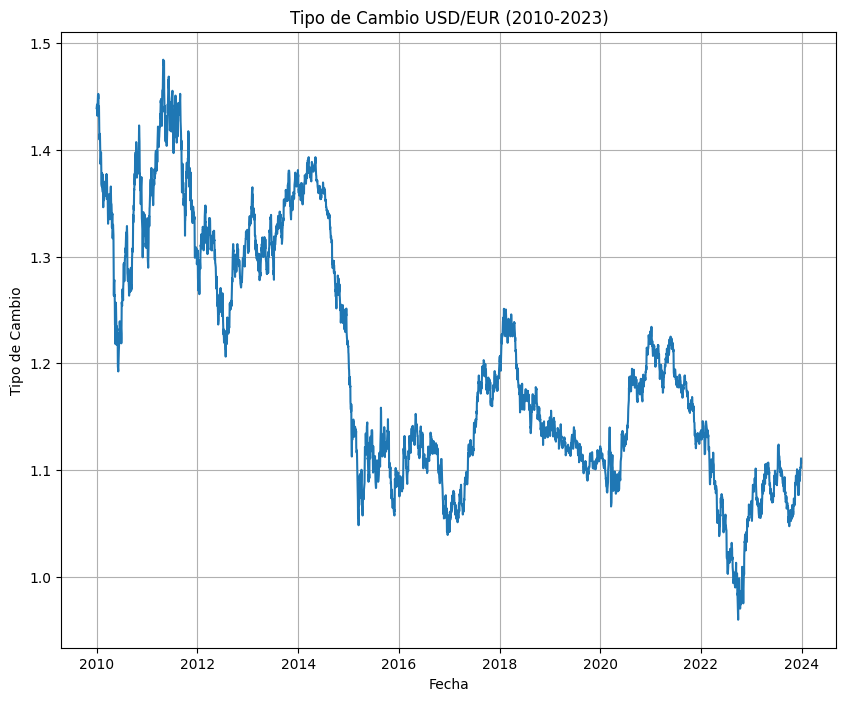

In [98]:
# Ahora convertimos el índice a formato datetime y aseguramos que la serie tenga una frecuencia diaria, rellenando los días faltantes con NaN.

usd_eur.index = pd.to_datetime(usd_eur.index)
usd_eur = usd_eur.asfreq('D').dropna()

# Después, visualizamos la serie temporal para entender su comportamiento a lo largo del tiempo.

plt.figure(figsize=(10,8))
plt.plot(usd_eur['Close'], label='Tipo de Cambio USD/EUR')
plt.title('Tipo de Cambio USD/EUR (2010-2023)')
plt.xlabel('Fecha')
plt.ylabel('Tipo de Cambio')
plt.grid()
plt.show()

La gráfica anterior muestra la evolución del tipo de cambio USD/EUR entre 2010 y 2023. Se observa una tendencia general a la baja, lo que indica que el euro se ha debilitado frente al dólar con el tiempo.

También hay alta volatilidad, con múltiples subidas y bajadas. Destacan una caída importante alrededor de 2014–2015 y un valor cercano a la paridad (1 EUR ≈ 1 USD) en 2022.

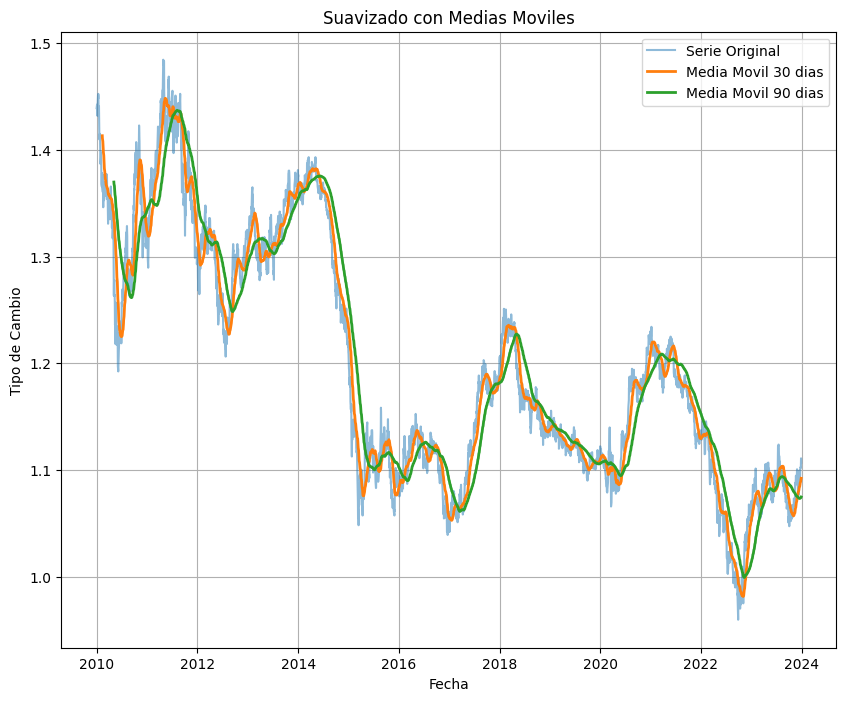

In [99]:
# Ahora aplicamos un suavizado utilizando medias móviles para observar las tendencias a corto y largo plazo en la serie temporal.

usd_eur['SMA_30'] = usd_eur['Close'].rolling(window=30).mean()
usd_eur['SMA_90'] = usd_eur['Close'].rolling(window=90).mean()

# Visualizamos la serie original junto con las medias móviles para comparar las tendencias.

plt.figure(figsize=(10,8))
plt.plot(usd_eur['Close'], label='Serie Original', alpha=0.5)
plt.plot(usd_eur['SMA_30'], label='Media Movil 30 dias', linewidth=2)
plt.plot(usd_eur['SMA_90'], label='Media Movil 90 dias', linewidth=2)
plt.title('Suavizado con Medias Moviles')
plt.xlabel('Fecha')
plt.ylabel('Tipo de Cambio')
plt.legend()
plt.grid()
plt.show()

En el grafico anterior se aplican medias móviles de 30 y 90 días para suavizar la serie y reducir la volatilidad. Esto permite observar con mayor claridad la tendencia general a la baja.

La media de 30 días reacciona más rápido a los cambios, mientras que la de 90 días muestra una tendencia más estable y suavizada.

In [100]:
# En esta celda realizamos la prueba de Dickey-Fuller aumentada para verificar la estacionariedad de la serie temporal.

adf_tets = adfuller(usd_eur['Close'])
print(f"ADF Statistic: {adf_tets[0]}")
print(f"p-values: {adf_tets[1]}")

ADF Statistic: -2.2885848747012068
p-values: 0.17567601123937715


La prueba de Dickey-Fuller aumentada (ADF) arroja un **p-value de 0.175**, mayor a 0.05, lo que indica que la serie **no es estacionaria**.

Esto significa que la serie tiene tendencia o cambios en el tiempo, por lo que será necesario aplicar transformaciones (como diferenciación) antes de modelar.


In [101]:
# Para hacer la serie estacionaria, aplicamos la diferenciación a la serie temporal.

usd_eur['Diff'] = usd_eur['Close'].diff().dropna()

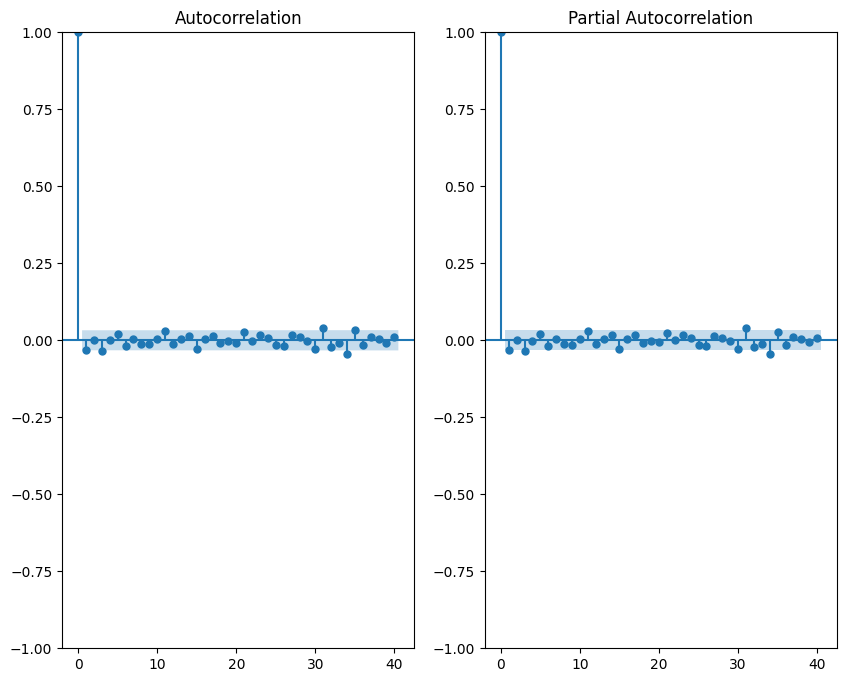

In [102]:
# Ahora visualizamos las funciones de autocorrelación (ACF) y autocorrelación parcial (PACF) para la serie diferenciada para identificar posibles modelos ARIMA.

fig, axes = plt.subplots(1, 2, figsize=(10, 8))
plot_acf(usd_eur['Diff'].dropna(), lags=40, ax=axes[0])
plot_pacf(usd_eur['Diff'].dropna(), lags=40, ax=axes[1])
plt.show()

Las gráficas de autocorrelación (ACF) y autocorrelación parcial (PACF) muestran que, excepto en el rezago 0, los valores están cercanos a cero.

Esto indica que no hay una correlación significativa entre los valores pasados, lo que sugiere un comportamiento cercano a ruido blanco y dificulta identificar patrones claros para modelos AR o MA.

In [103]:
# Basándonos en las gráficas de ACF y PACF, seleccionamos un modelo ARIMA(1, 1, 1) para ajustar la serie temporal diferenciada.

train_size = int(len(usd_eur) * 0.8)
train, test = usd_eur ['Close'][:train_size], usd_eur['Close'][train_size:]
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()
print (model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:               EURUSD=X   No. Observations:                 2916
Model:                 ARIMA(1, 1, 1)   Log Likelihood               10355.064
Date:                Sun, 22 Mar 2026   AIC                         -20704.129
Time:                        19:23:22   BIC                         -20686.196
Sample:                             0   HQIC                        -20697.669
                               - 2916                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4789      0.305     -1.569      0.117      -1.077       0.119
ma.L1          0.4440      0.312      1.422      0.155      -0.168       1.056
sigma2      4.808e-05   8.54e-07     56.279      0.0

c:\Users\yolic\OneDrive\Desktop\Practicas_y_ejercicios_Datos_y_programacion\pythonenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\yolic\OneDrive\Desktop\Practicas_y_ejercicios_Datos_y_programacion\pythonenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\yolic\OneDrive\Desktop\Practicas_y_ejercicios_Datos_y_programacion\pythonenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


En el resultado anterior, se ajusta un modelo ARIMA(1,1,1) a la serie temporal. Los coeficientes AR (ar.L1) y MA (ma.L1) presentan p-values mayores a 0.05, lo que indica que no son estadísticamente significativos y que el modelo no está capturando bien la dinámica de la serie.

El modelo muestra valores de AIC y BIC que sirven como referencia para comparar con otros modelos, pero por sí solos no garantizan un buen ajuste.

En cuanto a los residuos, la prueba de Ljung-Box sugiere que no hay autocorrelación significativa, lo cual es positivo. Sin embargo, la prueba de Jarque-Bera indica que los residuos no siguen una distribución normal, lo que puede afectar la calidad del modelo.

En conjunto, aunque el modelo logra ajustarse, los resultados sugieren que no es el modelo más adecuado, por lo que sería recomendable probar otras configuraciones de ARIMA.

c:\Users\yolic\OneDrive\Desktop\Practicas_y_ejercicios_Datos_y_programacion\pythonenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\yolic\OneDrive\Desktop\Practicas_y_ejercicios_Datos_y_programacion\pythonenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


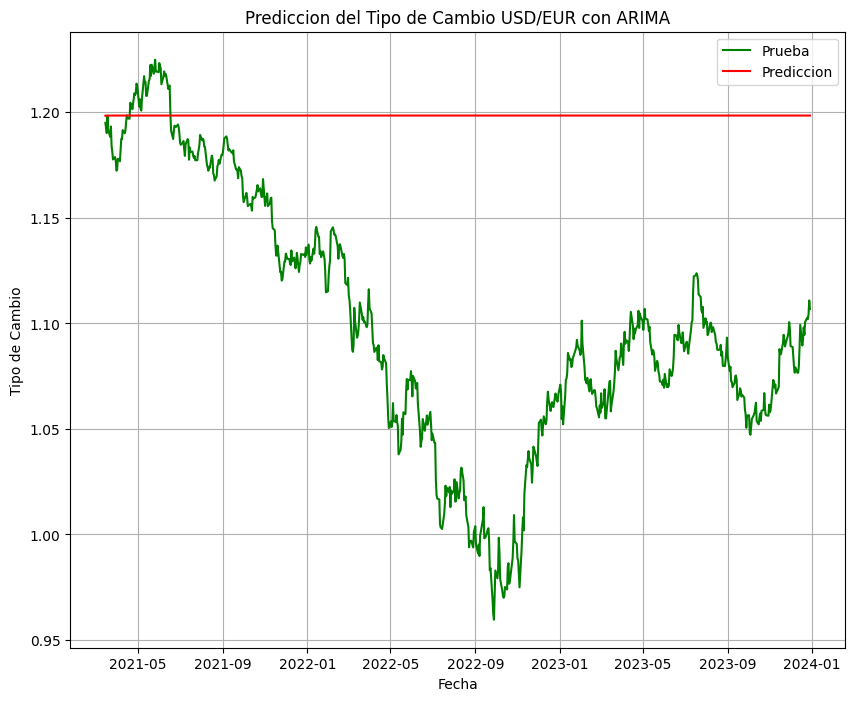

In [104]:
# Ahora realizamos la predicción para el conjunto de prueba utilizando el modelo ARIMA ajustado.

forecast = model_fit.forecast(steps=len(test))

# Finalmente, visualizamos la serie temporal original junto con las predicciones para evaluar el desempeño del modelo.

plt.figure(figsize=(10, 8))
plt.plot(test, label='Prueba', color='green')
plt.plot(test.index, forecast, label='Prediccion', color='red')
plt.title('Prediccion del Tipo de Cambio USD/EUR con ARIMA')
plt.xlabel('Fecha')
plt.ylabel('Tipo de Cambio')
plt.legend()
plt.grid()
plt.show()

En el grafico de arriba, la predicción del modelo ARIMA se muestra como una línea casi constante, lo que indica que el modelo no logra capturar la variabilidad real de la serie.

Esto sugiere que el modelo tiene un bajo poder predictivo y no se ajusta bien al comportamiento cambiante de los datos.

In [105]:
# Evaluamos el desempeño del modelo utilizando métricas como MAE, MSE y RMSE.

mae = mean_absolute_error(test, forecast)
mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

MAE: 0.10119934480523196
MSE: 0.013658101215266939
RMSE: 0.1168678793136375


Las métricas muestran el error del modelo en las predicciones. El MAE y RMSE indican que, en promedio, el modelo se equivoca por alrededor de 0.10–0.11 unidades en el tipo de cambio.

Esto confirma que el modelo tiene precisión limitada, consistente con la gráfica de predicción donde no logra capturar bien la variabilidad de la serie.

In [106]:
# Finalmente, realizamos una descomposición estacional para analizar las componentes de tendencia, estacionalidad y residuales de la serie temporal.

decomposition = seasonal_decompose(usd_eur['Close'], model='additive', period=365)

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

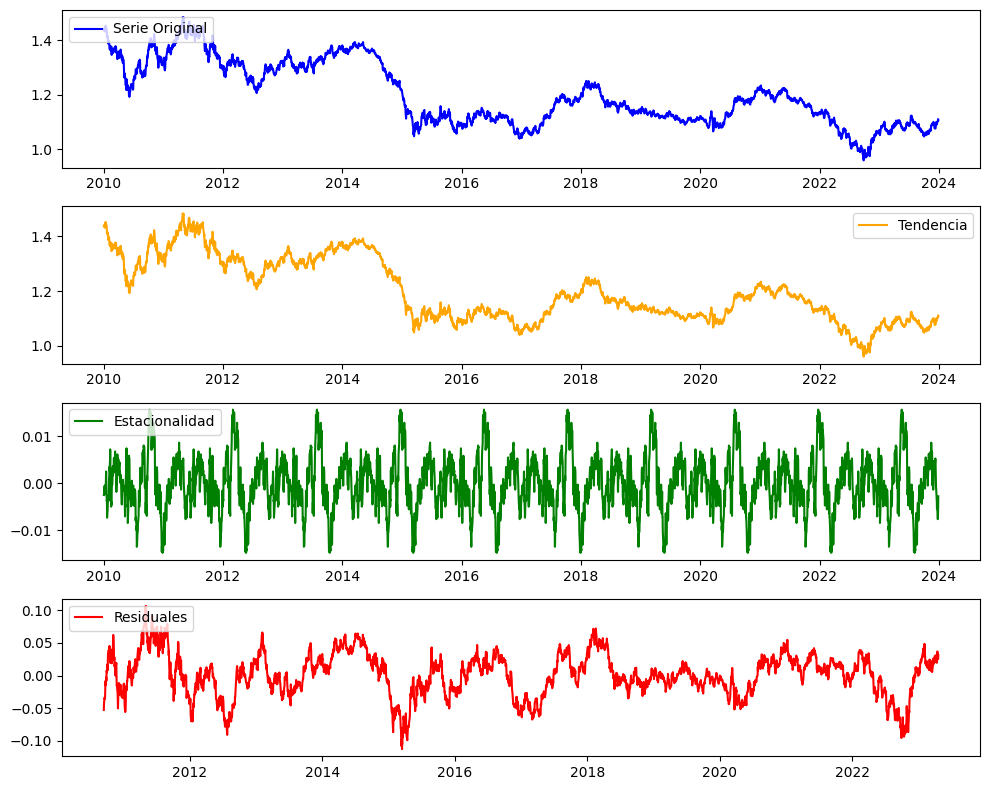

In [107]:
# Visualizamos cada componente de la descomposición para entender mejor la estructura de la serie temporal.

plt.figure(figsize=(10, 8))

plt.subplot(411)
plt.plot(usd_eur['Close'], label='Serie Original', color='blue')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(usd_eur['Close'], label='Tendencia', color='orange')
plt.legend()

plt.subplot(413)
plt.plot(seasonal, label='Estacionalidad', color='green')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(residual, label='Residuales', color='red')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

La descomposición de la serie muestra que existe una tendencia clara a la baja en el tipo de cambio. La componente de estacionalidad es pequeña, lo que indica que no hay patrones periódicos fuertes.

Los residuales parecen comportarse de forma aleatoria, lo que sugiere que la mayor parte de la estructura de la serie está explicada por la tendencia.

------------------------------------------------------------------------------------
### Conclusión

El análisis de la serie temporal del tipo de cambio USD/EUR muestra una tendencia general a la baja y alta volatilidad, sin evidencia de estacionalidad significativa. La prueba ADF confirma que la serie no es estacionaria, lo que justifica la aplicación de diferenciación.

Aunque se probó un modelo ARIMA(1,1,1), los resultados indican que no logra capturar adecuadamente la dinámica de la serie, reflejado en coeficientes no significativos y predicciones poco precisas.

En conjunto, esto sugiere que el comportamiento del tipo de cambio es complejo y podría requerir modelos más avanzados o la incorporación de variables externas para mejorar la capacidad predictiva.